In [1]:
import mne
import mne.viz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

epochs = mne.read_epochs(
    "derivatives/preprocessed/epochs/sub-01_eeg_epo.fif",
    preload=True
)

print(epochs)

Reading /Users/lohwenliang/ds005811/derivatives/preprocessed/epochs/sub-01_eeg_epo.fif ...
    Found the data of interest:
        t =    -100.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 18 columns
4000 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 4000 events (all good), -0.1 – 0.8 s (baseline -0.1 – 0 s), ~427.7 MiB, data loaded, with metadata,
 'stim_on': 4000>


In [2]:
epochs.info

<Info | 15 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, AF3, AF4, F7, F5, F3, F1, Fz, F2, F4, F6, F8, ...
 chs: 62 EEG
 custom_ref_applied: True
 description: Anonymized using a time shift to preserve age at acquisition
 dig: 65 items (3 Cardinal, 62 EEG)
 experimenter: mne_anonymize
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 line_freq: 50.0
 lowpass: 40.0 Hz
 meas_date: 2021-04-28 17:48:26 UTC
 meas_id: 4 items (dict)
 nchan: 62
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: sub-01, sex: 2, hand: 0>
>

In [3]:
print(epochs.events.shape)
print(epochs.event_id)
print(epochs.annotations)

(4000, 3)
{'stim_on': 4}
None


In [4]:
# display metadata of epochs
print(epochs.metadata.columns)

print(epochs.metadata.head())

for col in epochs.metadata.columns:
    print("\n", col)
    print(epochs.metadata[col].unique()[:20])

Index(['event_name', 'task', 'subject', 'session', 'run', 'image_id',
       'class_id', 'class', 'super_class', 'stim_is_animate',
       'resp_is_animate', 'resp_is_right', 'RT', 'stim_is_face', 'face_score',
       'face_score_max', 'face_area', 'face_area_max'],
      dtype='str')
  event_name      task  subject     session  run         image_id   class_id  \
0    stim_on  ImageNet        1  ImageNet01    1  n03594734_45507  n03594734   
1    stim_on  ImageNet        1  ImageNet01    1    n02865351_847  n02865351   
2    stim_on  ImageNet        1  ImageNet01    1   n01983481_8224  n01983481   
3    stim_on  ImageNet        1  ImageNet01    1  n02841315_24983  n02841315   
4    stim_on  ImageNet        1  ImageNet01    1   n04483307_1497  n04483307   

              class   super_class  stim_is_animate  resp_is_animate  \
0              jean      covering            False            False   
1          bolo tie      covering            False            False   
2  American lobster 

In [5]:
%cat sub-01/ses-ImageNet01/eeg/sub-01_ses-ImageNet01_task-ImageNet_run-01_events.tsv

onset	duration	trial_type	value	sample	StimulusPresentation
0.0	0.002	begin	1	0	PsychophysicsToolbox
0.498	0.002	stim_on	4	249	PsychophysicsToolbox
1.3	0.002	resp	3	650	PsychophysicsToolbox
1.314	0.002	resp	3	657	PsychophysicsToolbox
1.324	0.002	resp	3	662	PsychophysicsToolbox
1.34	0.002	resp	3	670	PsychophysicsToolbox
1.35	0.002	resp	3	675	PsychophysicsToolbox
1.36	0.002	resp	3	680	PsychophysicsToolbox
1.37	0.002	resp	3	685	PsychophysicsToolbox
1.38	0.002	resp	3	690	PsychophysicsToolbox
1.39	0.002	resp	3	695	PsychophysicsToolbox
1.406	0.002	resp	3	703	PsychophysicsToolbox
2.068	0.002	stim_on	4	1034	PsychophysicsToolbox
2.16	0.002	resp	3	1080	PsychophysicsToolbox
2.184	0.002	resp	3	1092	PsychophysicsToolbox
2.194	0.002	resp	3	1097	PsychophysicsToolbox
2.204	0.002	resp	3	1102	PsychophysicsToolbox
2.214	0.002	resp	3	1107	PsychophysicsToolbox
2.224	0.002	resp	3	1112	PsychophysicsToolbox
2.24	0.002	resp	3	1120	PsychophysicsToolbox
2.25	0.002	resp	3	1125	PsychophysicsToolbox
2.26	0.002	resp

In [6]:
%cat sub-01/ses-ImageNet01/eeg/sub-01_ses-ImageNet01_task-ImageNet_run-01_events.json

{
  "onset": {
    "Description": "Onset (in seconds) of the event from the beginning of the first datapoint. Negative onsets account for events before the first stored data point.",
    "Units": "s"
  },
  "duration": {
    "Description": "Duration of the event in seconds from onset. Must be zero, positive, or 'n/a' if unavailable. A zero value indicates an impulse event. ",
    "Units": "s"
  },
  "sample": {
    "Description": "The event onset time in number of sampling points.First sample is 0."
  },
  "value": {
    "Description": "The event code (also known as trigger code or event ID) associated with the event."
  },
  "trial_type": {
    "Description": "The type, category, or name of the event."
  },
  "StimulusPresentation": {
    "ScreenDistance": 0.7,
    "ScreenResolution": [
      1024,
      768
    ],
    "ScreenSize": [
      0.6,
      0.6
    ],
    "SoftwareName": "Psychtoolbox",
    "SoftwareVersion": "3.0"
  }
}

In [7]:
# display super classes of objects
print(
    epochs.metadata["super_class"]
    .value_counts()
)

super_class
canine                  520
device                  496
container               372
covering                344
invertebrate            244
bird                    236
structure               228
food                    152
equipment               148
reptile                 144
implement               144
artifact                120
conveyance              116
furnishing               96
mammal                   92
primate                  80
ungulate                 68
fish                     64
fruit                    64
carnivore                60
feline                   52
geological_formation     36
amphibian                32
fungus                   28
toiletry                 24
person                   12
abstraction              12
plant                     8
bar                       4
substance                 4
Name: count, dtype: int64


In [8]:
# display classes of objects
print(
    epochs.metadata["class"]
    .value_counts()
    .head(20)
)

class
crane                     8
maillot                   8
jean                      4
bolo tie                  4
American lobster          4
binoculars                4
trimaran                  4
safe                      4
red-breasted merganser    4
projector                 4
Ibizan hound              4
Angora                    4
lumbermill                4
fire engine               4
alp                       4
gar                       4
bagel                     4
palace                    4
cheetah                   4
bull mastiff              4
Name: count, dtype: int64


In [9]:
# plotting epoched data over 4 sessions
epochs.plot()

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x37c4379b0) at 0x38a48b080>

In [10]:
animate_epochs = epochs[
    epochs.metadata["stim_is_animate"] == True
]

In [11]:
# plotting animate epochs
animate_epochs.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x106118640) at 0x38c804840>

In [12]:
inanimate_epochs = epochs[
    epochs.metadata["stim_is_animate"] == False
]

In [13]:
# plotting inanimate epochs
inanimate_epochs.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x12ee67a70) at 0x3e5c43b40>

In [14]:
# creating averaged data
evoked = epochs.average()

In [15]:
evoked

<Evoked | 'stim_on' (average, N=4000), -0.1 – 0.8 s, baseline -0.1 – 0 s, 62 ch, ~186 KiB>

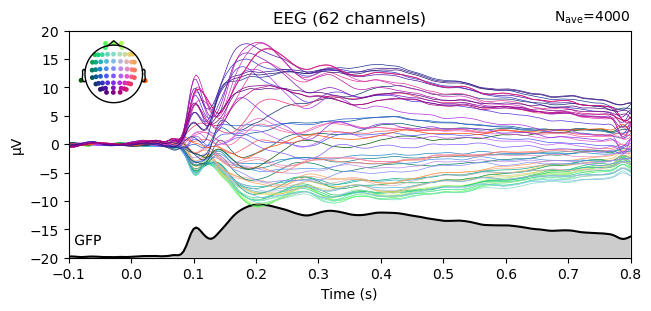

In [16]:
# plotting averaged data
evoked.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-20, 20]));

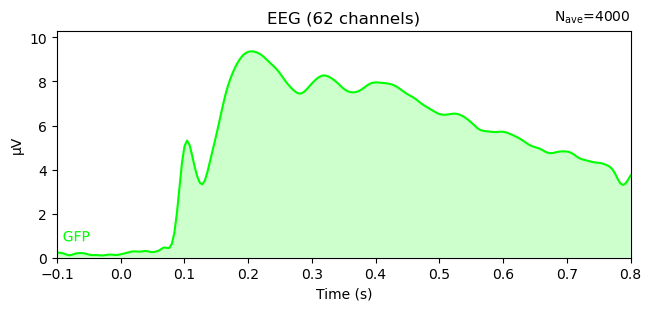

In [17]:
# plotting GFP
evoked.plot(gfp="only");

In [18]:
animate_evoked = animate_epochs.average()

In [19]:
animate_evoked

<Evoked | 'stim_on' (average, N=1640), -0.1 – 0.8 s, baseline -0.1 – 0 s, 62 ch, ~186 KiB>

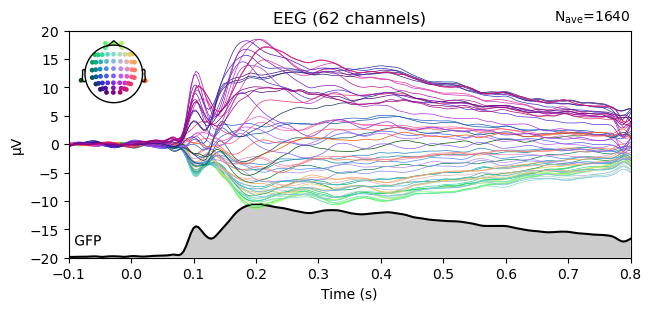

In [20]:
# plotting averaged data for animate condition
animate_evoked.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-20, 20]));

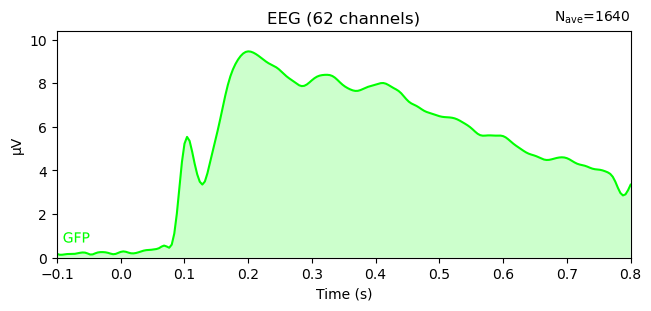

In [21]:
# plotting GFP for animate condition
animate_evoked.plot(gfp="only");

In [22]:
inanimate_evoked = inanimate_epochs.average()

In [23]:
inanimate_evoked

<Evoked | 'stim_on' (average, N=2360), -0.1 – 0.8 s, baseline -0.1 – 0 s, 62 ch, ~186 KiB>

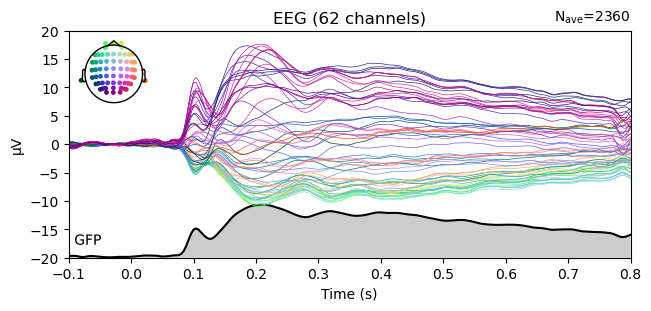

In [24]:
# plotting averaged data for inanimate condition
inanimate_evoked.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-20, 20]));

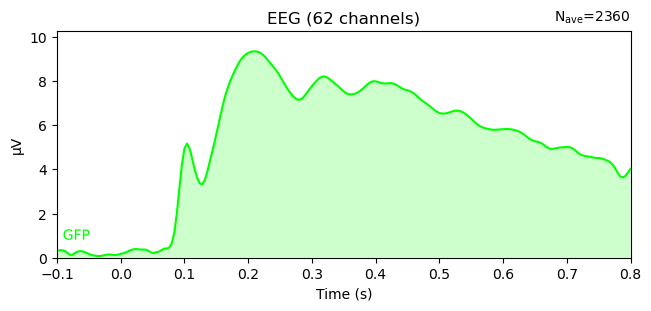

In [25]:
# plotting GFP for inanimate condition
inanimate_evoked.plot(gfp="only");

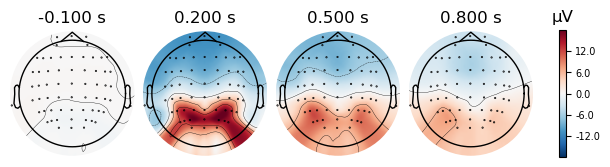

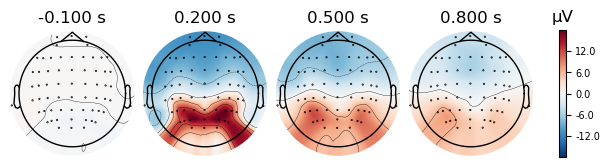

In [26]:
# display topomaps of the average evoked potential
evoked.plot_topomap(
    times=[-0.1, 0.2, 0.5, 0.8]
)

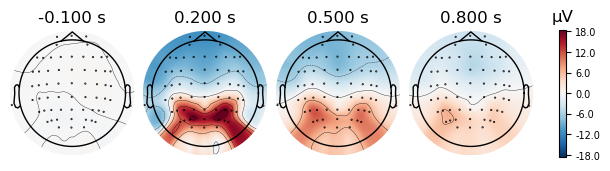

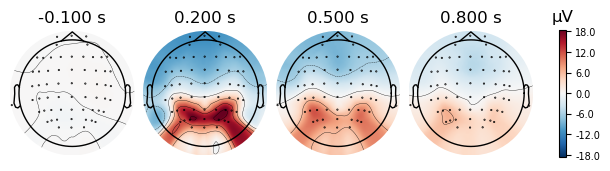

In [27]:
# display topomaps of the average evoked potential for animate condition
animate_evoked.plot_topomap(
    times=[-0.1, 0.2, 0.5, 0.8]
)

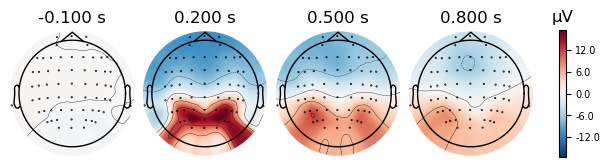

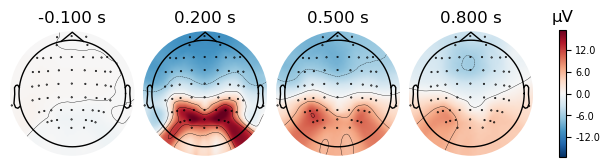

In [28]:
# display topomaps of the average evoked potential for inanimate condition
inanimate_evoked.plot_topomap(
    times=[-0.1, 0.2, 0.5, 0.8]
)

No projector specified for this dataset. Please consider the method self.add_proj.


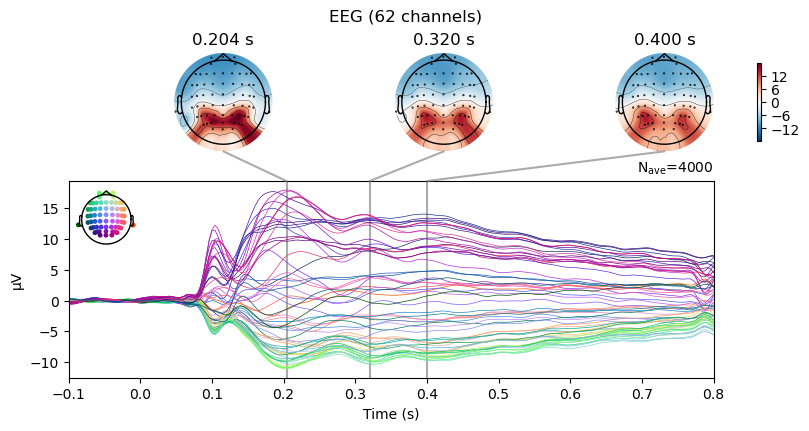

In [29]:
# display topomaps of the average evoked potential
evoked.plot_joint();

No projector specified for this dataset. Please consider the method self.add_proj.


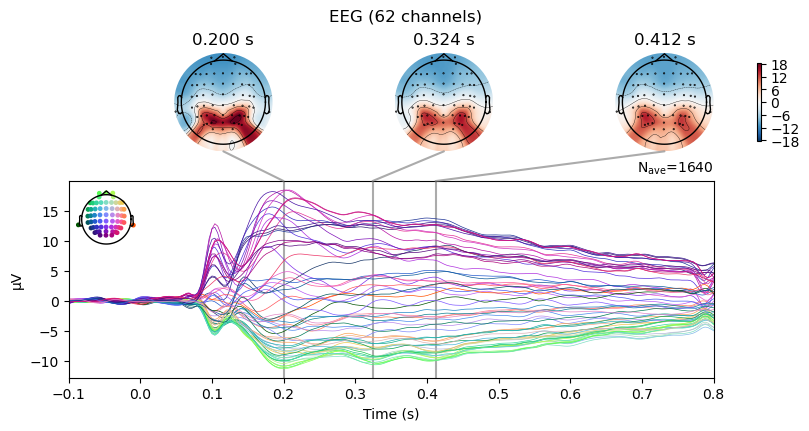

In [30]:
# display topomaps of the average evoked potential
animate_evoked.plot_joint();

No projector specified for this dataset. Please consider the method self.add_proj.


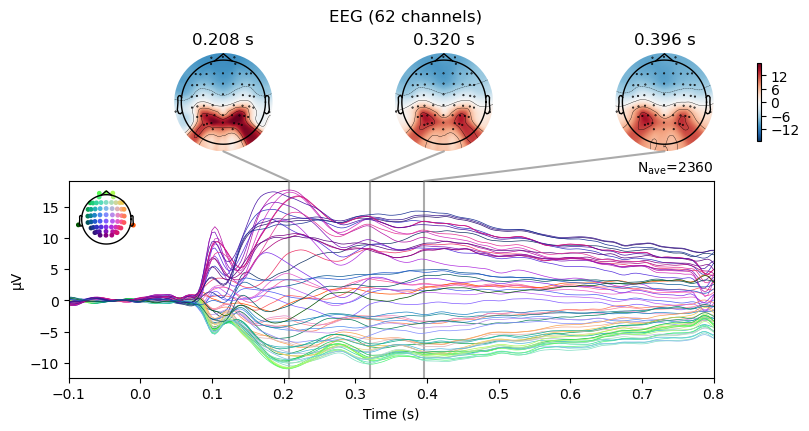

In [31]:
# display topomaps of the average evoked potential
inanimate_evoked.plot_joint();

In [33]:
# averaging across channels with ROIs
v1 = ["Oz", "O1", "O2", "POz", "PO3", "PO4"]
loc = ["PO7", "PO8", "P7", "P8"]
parieto_central = ["Pz", "CPz", "Cz"]

v1_ix = mne.pick_channels(epochs.info["ch_names"], include=v1)
loc_ix = mne.pick_channels(epochs.info["ch_names"], include=loc)
parieto_central_ix = mne.pick_channels(epochs.info["ch_names"], include=parieto_central)

In [34]:
roi_dict = dict(v1_ROI=v1_ix, loc_ROI=loc_ix, parieto_central_ROI=parieto_central_ix)
roi_evoked = mne.channels.combine_channels(epochs, roi_dict, method="mean")
print(roi_evoked.info["ch_names"])
roi_evoked.plot()

Not setting metadata
4000 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Adding metadata with 18 columns
['v1_ROI', 'loc_ROI', 'parieto_central_ROI']


<mne_qt_browser._pg_figure.MNEQtBrowser(0x31a5834b0) at 0x3f93d8800>

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


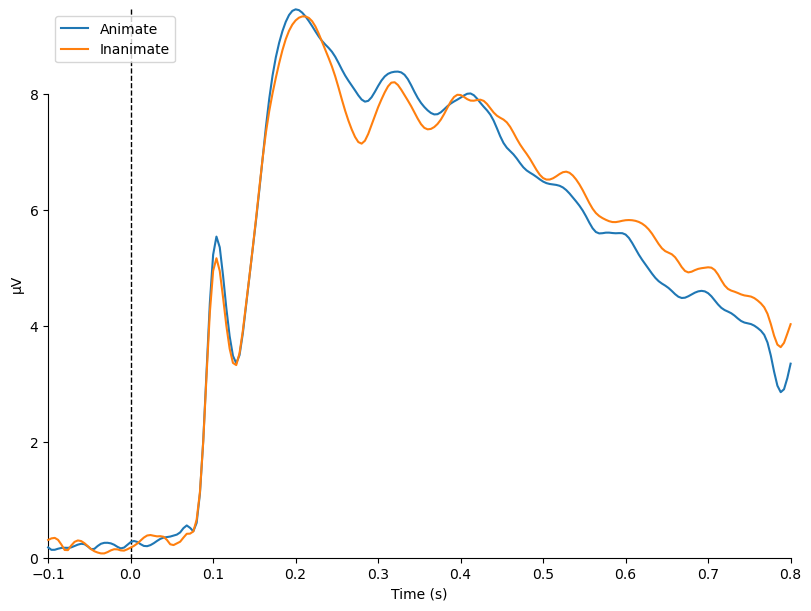

[<Figure size 800x600 with 1 Axes>]

In [32]:
# comparing conditions
mne.viz.plot_compare_evokeds(
    {
        "Animate": animate_evoked,
        "Inanimate": inanimate_evoked
    }
)